# 02 — Preprocessing
Synthetic ICU Mortality Prediction (24-hour dataset)

This notebook demonstrates the preprocessing pipeline used across the
project: the three feature-set experiments (clinical / topic / combined),
stratified train/test splitting, and SMOTE oversampling applied only to
training data.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import (
    load_data, FEATURE_SETS, CLINICAL_FEATURES, TOPIC_FEATURES, COMBINED_FEATURES,
    get_feature_target, train_test_split_stratified, apply_smote, OUTCOME_COLS,
)

df = load_data('../data/synthetic_icu_24h.csv')
df.shape

(27809, 28)

## Feature-set experiments

Three feature configurations are evaluated in this project:

| Experiment | Features |
|---|---|
| `clinical` | 12 structured clinical variables only |
| `topic`    | 10 LDA-style topic probability features only |
| `combined` | clinical + topic (22 features) |

This lets us test whether the synthetic topic features add predictive value
on top of the structured clinical variables — mirroring the paper's central
question about semi-structured text data.

In [2]:
for name, feats in FEATURE_SETS.items():
    print(f"{name:10s}: {len(feats)} features")
    print(f"           {feats}\n")

clinical  : 12 features
           ['x1_gcs', 'x2_heart_rate', 'x3_sbp', 'x4_temp_c', 'x5_bun', 'x6_wbc', 'x7_potassium', 'x8_sodium', 'x9_bicarbonate', 'x10_admission_type', 'x11_gender', 'x12_age']

topic     : 10 features
           ['topicB_hydroperitoneum', 'topicB_urinary_retention', 'topicB_newborn_resp_distress', 'topicB_coronary_artery_disease', 'topicB_pneumothorax_effusion', 'topicB_nursing_assessment', 'topicB_endotracheal_intubation', 'topicB_sepsis', 'topicB_medical_assessment', 'topicB_spinal_hematoma']

combined  : 22 features
           ['x1_gcs', 'x2_heart_rate', 'x3_sbp', 'x4_temp_c', 'x5_bun', 'x6_wbc', 'x7_potassium', 'x8_sodium', 'x9_bicarbonate', 'x10_admission_type', 'x11_gender', 'x12_age', 'topicB_hydroperitoneum', 'topicB_urinary_retention', 'topicB_newborn_resp_distress', 'topicB_coronary_artery_disease', 'topicB_pneumothorax_effusion', 'topicB_nursing_assessment', 'topicB_endotracheal_intubation', 'topicB_sepsis', 'topicB_medical_assessment', 'topicB_spinal

## Target selection
This project focuses on the 24h dataset predicting `mortality_in_hospital`, but the same pipeline works for any of the 5 outcome columns.

In [3]:
TARGET = 'mortality_in_hospital'

X, y = get_feature_target(df, feature_set='combined', target=TARGET)
print("X shape:", X.shape)
print("y positive rate: {:.2f}%".format(y.mean() * 100))

X shape: (27809, 22)
y positive rate: 9.31%


## Stratified train/test split

We hold out 25% of the data as a test set, stratified so the mortality rate stays the same in both splits. The test set is **never touched** by SMOTE or used during model selection.

In [4]:
X_train, X_test, y_train, y_test = train_test_split_stratified(X, y, test_size=0.25)

print("Train shape:", X_train.shape, " | positive rate: {:.2f}%".format(y_train.mean()*100))
print("Test shape: ", X_test.shape, " | positive rate: {:.2f}%".format(y_test.mean()*100))

Train shape: (20856, 22)  | positive rate: 9.31%
Test shape:  (6953, 22)  | positive rate: 9.31%


## Class imbalance and SMOTE

The workflow: split first, then apply SMOTE only to the training set.

Before SMOTE: (20856, 22)  | positive rate: 9.31%
After SMOTE:  (37828, 22)  | positive rate: 50.00%


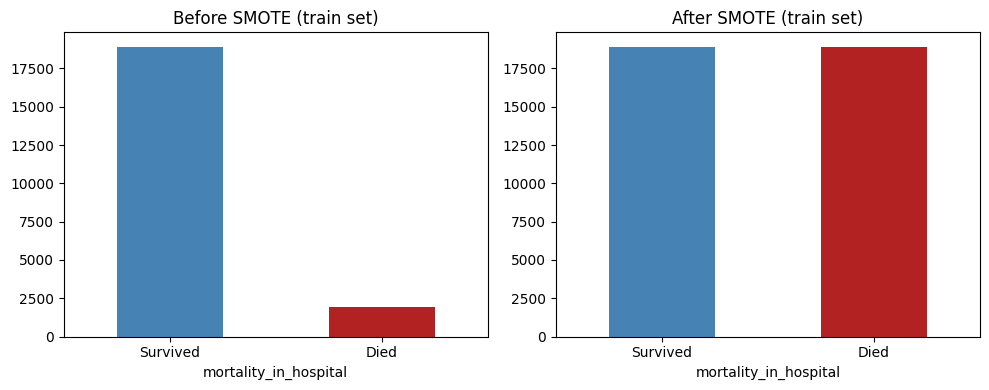

In [5]:
X_train_bal, y_train_bal = apply_smote(X_train, y_train)

print("Before SMOTE:", X_train.shape, " | positive rate: {:.2f}%".format(y_train.mean()*100))
print("After SMOTE: ", X_train_bal.shape, " | positive rate: {:.2f}%".format(y_train_bal.mean()*100))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'firebrick'])
axes[0].set_title('Before SMOTE (train set)')
axes[0].set_xticklabels(['Survived', 'Died'], rotation=0)

y_train_bal.value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'firebrick'])
axes[1].set_title('After SMOTE (train set)')
axes[1].set_xticklabels(['Survived', 'Died'], rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/preprocessing_smote_balance.png', dpi=150)
plt.show()

## Why SMOTE is applied post-split, not pre-split

If SMOTE were applied *before* the train/test split, synthetic minority-class
samples generated from a "died" patient could end up in the test set as a
near-duplicate of a training sample — leaking information and inflating
apparent performance. Splitting first, then oversampling only the training
fold, avoids this.

## Verifying the 3 feature-experiment splits work end-to-end

In [6]:
for exp_name in FEATURE_SETS:
    X_exp, y_exp = get_feature_target(df, feature_set=exp_name, target=TARGET)
    X_tr, X_te, y_tr, y_te = train_test_split_stratified(X_exp, y_exp)
    X_tr_bal, y_tr_bal = apply_smote(X_tr, y_tr)
    print(f"{exp_name:10s} -> X_train_bal: {X_tr_bal.shape}, X_test: {X_te.shape}")

clinical   -> X_train_bal: (37828, 12), X_test: (6953, 12)
topic      -> X_train_bal: (37828, 10), X_test: (6953, 10)


combined   -> X_train_bal: (37828, 22), X_test: (6953, 22)


## Summary

- Three feature sets are ready: `clinical` (12 features), `topic` (10 features),
  `combined` (22 features).
- Stratified 75/25 train/test split preserves class balance in both sets.
- SMOTE is applied only to training folds, bringing the minority class to 50%.

Next: `03_model_training.ipynb` trains CART, Logistic Regression, Random
Forest, Gradient Boosting, and a MARS-style model across all three feature
experiments, and saves metrics to `results/metrics/`.